<a href="https://colab.research.google.com/github/Krrish2708/Krish-Tewatia/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTING LIBRARIES AND LOADING DATASET**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/drug200.csv"
df = pd.read_csv(url)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


**BASIC STATISTICAL ANALYSIS**

In [ ]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (200, 6)


In [ ]:
print(df.columns)

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')


In [ ]:
df.dtypes

,0
Age,int64
Sex,object
BP,object
Cholesterol,object
Na_to_K,float64
Drug,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  199 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         199 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [ ]:
df.describe(include='object')

,Sex,BP,Cholesterol,Drug
count,200,200,199,199
unique,2,3,3,6
top,M,HIGH,HIGH,DrugY
freq,104,77,102,89


**HANDLING MISSING DATA**

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,1
Na_to_K,0
Drug,1


In [ ]:
df[df.isnull().any(axis=1)]

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
120,28,M,NORMAL,HIGH,27.064,NaN
194,46,F,HIGH,NaN,34.686,DrugY


In [ ]:
df["Cholesterol"].fillna(df["Cholesterol"].mode()[0], inplace=True)
df["Drug"].fillna(df["Drug"].mode()[0], inplace=True)

/tmp/ipykernel_2172/2081488897.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Cholesterol"].fillna(df["Cholesterol"].mode()[0], inplace=True)
/tmp/ipykernel_2172/2081488897.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


**DATA CLEANING**

In [ ]:
df.duplicated().sum()

np.int64(0)

NO DUPLICATES FOUND

In [ ]:
print(df.shape)

(200, 6)


**DATA TRANSFORMATION**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df["Sex"] = le.fit_transform(df["Sex"])
df["BP"] = le.fit_transform(df["BP"])
df["Cholesterol"] = le.fit_transform(df["Cholesterol"])
df["Drug"] = le.fit_transform(df["Drug"])

In [ ]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,1,25.355,1
1,47,1,1,1,13.093,4
2,47,1,1,1,10.114,4
3,28,0,2,1,7.798,5
4,61,0,1,1,18.043,1


In [ ]:
df.dtypes

,0
Age,int64
Sex,int64
BP,int64
Cholesterol,int64
Na_to_K,float64
Drug,int64


**UNIVARIATE ANALYSIS**

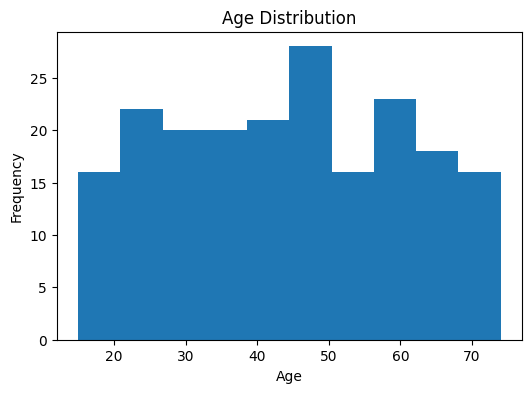

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

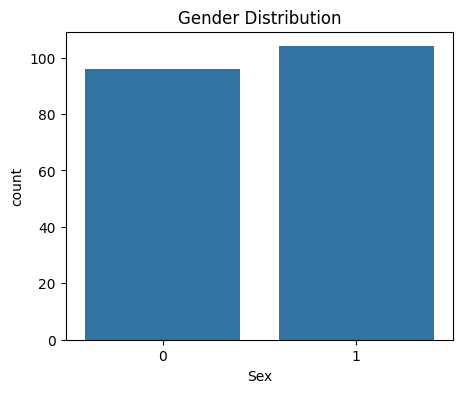

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

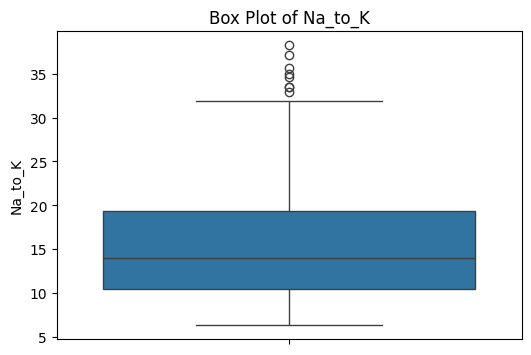

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Na_to_K"])
plt.title("Box Plot of Na_to_K")
plt.show()

**BIVARIATE ANALYSIS**

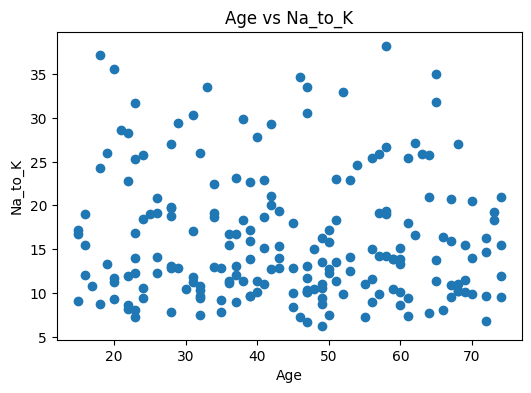

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Na_to_K"])
plt.title("Age vs Na_to_K")
plt.xlabel("Age")
plt.ylabel("Na_to_K")
plt.show()

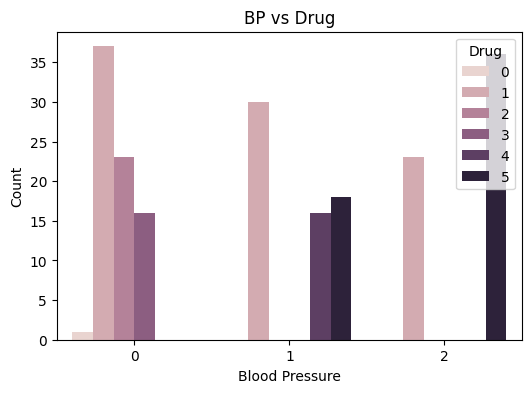

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="BP", hue="Drug", data=df)
plt.title("BP vs Drug")
plt.xlabel("Blood Pressure")
plt.ylabel("Count")
plt.show()

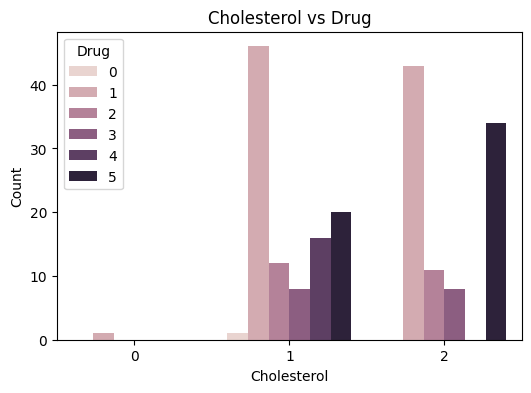

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Cholesterol", hue="Drug", data=df)
plt.title("Cholesterol vs Drug")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

**MULTIVARIATE ANALYSIS**

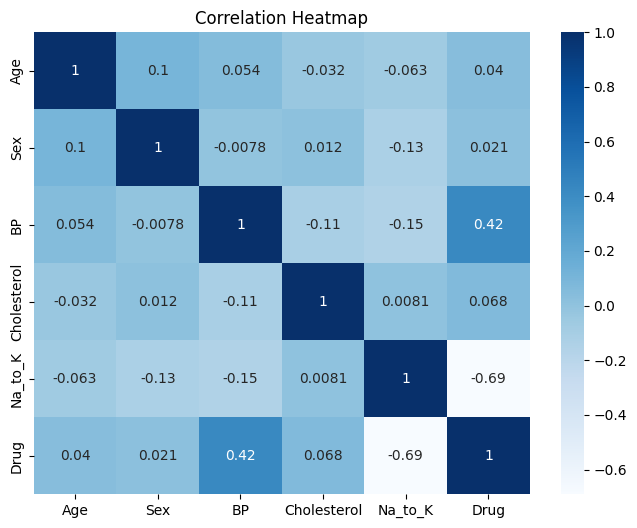

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

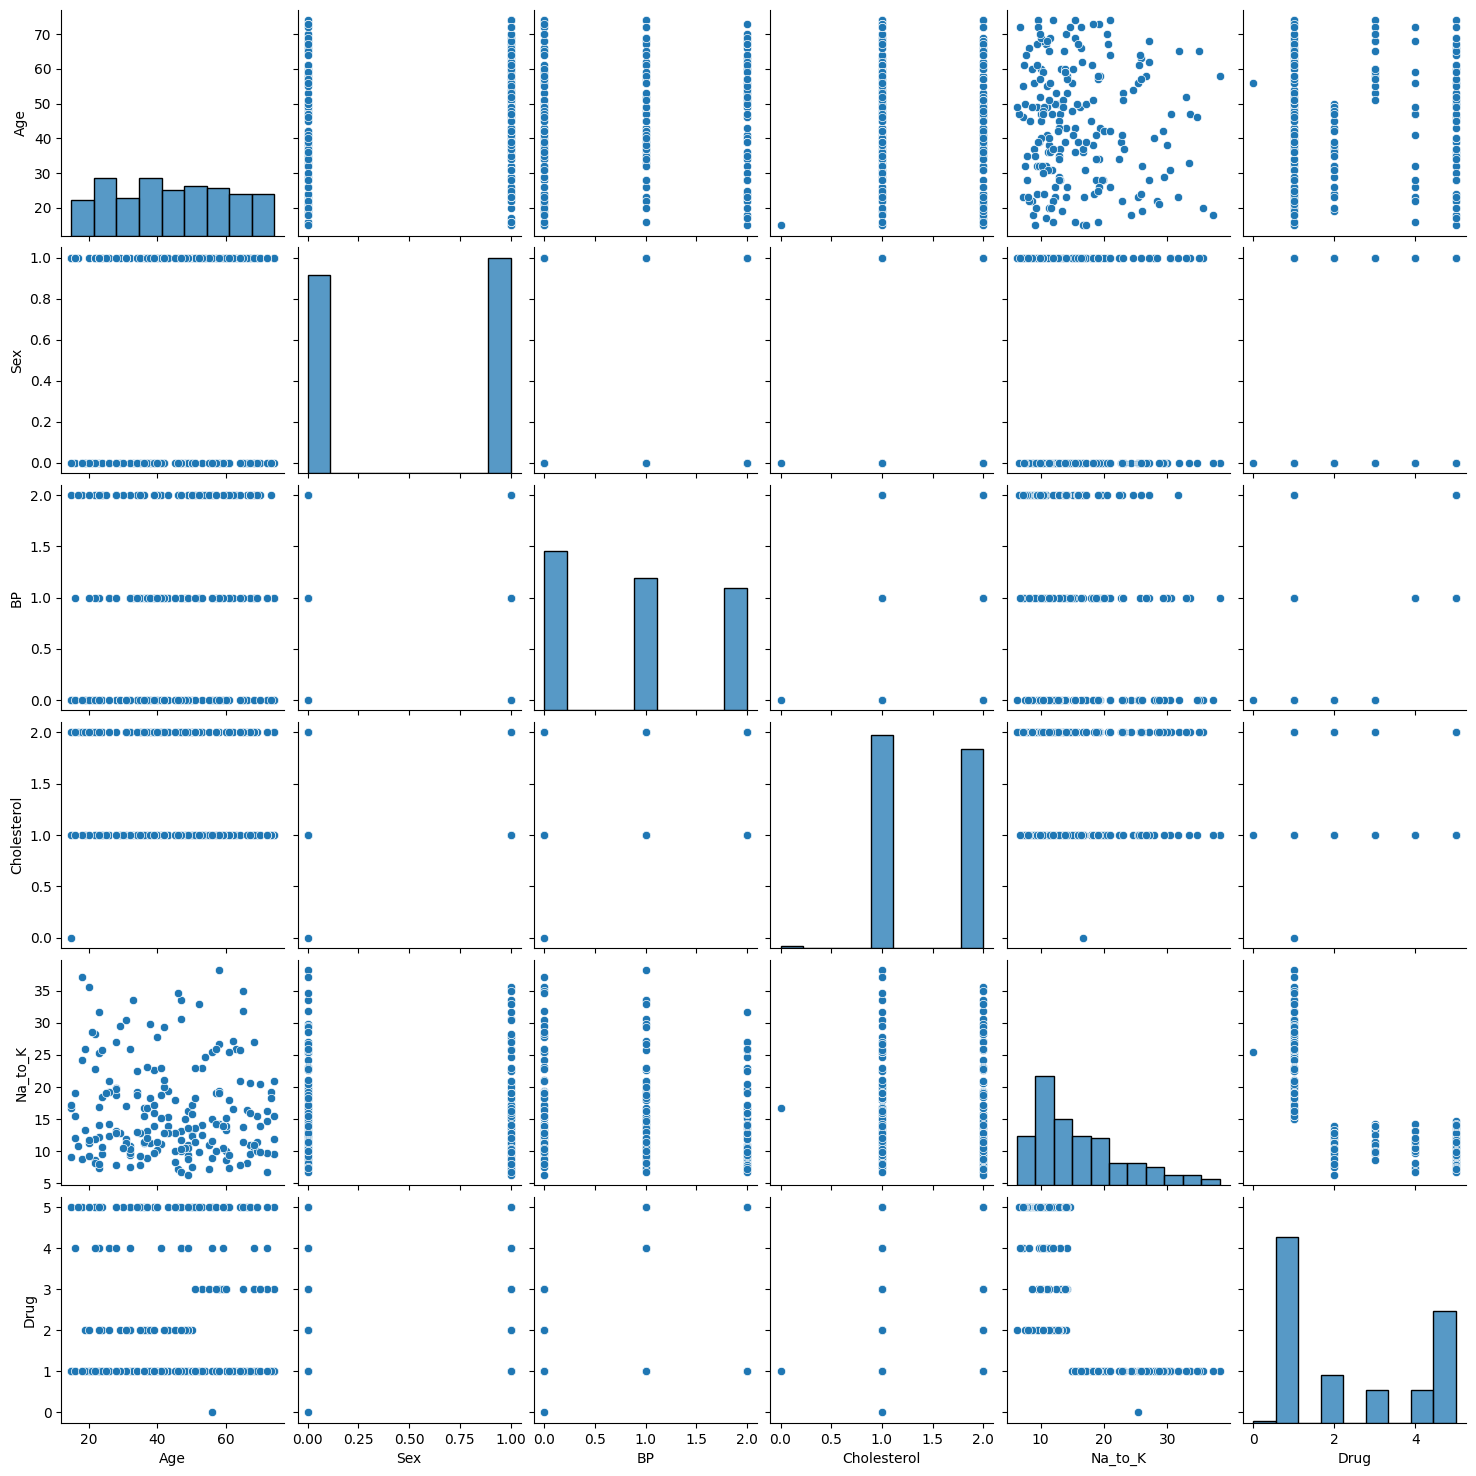

In [ ]:
sns.pairplot(df)
plt.show()

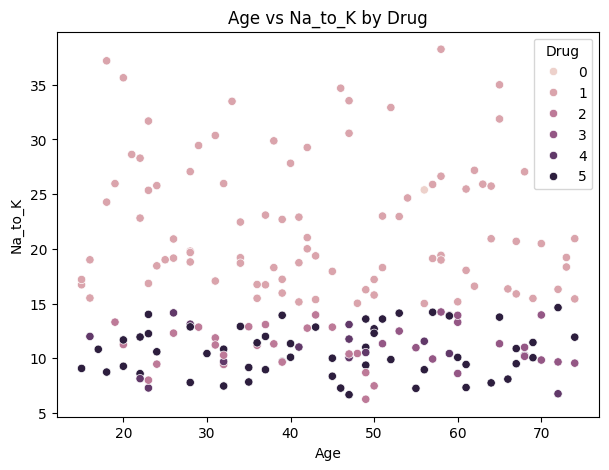

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age", y="Na_to_K", hue="Drug", data=df)
plt.title("Age vs Na_to_K by Drug")
plt.show()

## Conclusion

- The dataset contains 200 patient records with 6 attributes.
- Missing values were identified and handled successfully.
- No duplicate records were found in the dataset.
- Categorical data was transformed using Label Encoding.
- Univariate, bivariate and multivariate analyses were performed using different visualizations.
- The analysis helped understand the relationship between Age, Blood Pressure, Cholesterol, Na_to_K and Drug.


# Phase 2
#1D, 2D, 3D Statistical Analysis and Clustering

Dataset: Drug200

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, chi2_contingency, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/drug200.csv"
df = pd.read_csv(url)

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


# Understanding the Dataset

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (200, 6)

Columns:
['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']

Data types:
Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

Missing values:
Age            0
Sex            0
BP             0
Cholesterol    1
Na_to_K        0
Drug           1
dtype: int64

Duplicate rows: 0


# Cleaning the Data

In [3]:
df = df.replace(["?", "NA"], np.nan)

print(df.isnull().sum())

df = df.dropna().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)

Age            0
Sex            0
BP             0
Cholesterol    2
Na_to_K        0
Drug           2
dtype: int64

Shape after cleaning: (196, 6)


# 1D Statistical Analysis
## Numerical Variables

In [4]:
num_cols = ["Age", "Na_to_K"]

df[num_cols].describe()

,Age,Na_to_K
count,196.000000,196.000000
mean,44.479592,15.882791
std,16.517111,7.097593
min,15.000000,6.269000
25%,31.000000,10.443750
50%,45.000000,13.909000
75%,58.000000,19.204500
max,74.000000,38.247000


# Measures of Central Tendency

In [5]:
for col in num_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


 Age
Mean: 44.47959183673469
Median: 45.0
Mode: 47

 Na_to_K
Mean: 15.882790816326532
Median: 13.908999999999999
Mode: 12.006


# Quartiles and Percentiles

In [6]:
for col in num_cols:
    print("\n", col)
    print("Q1:", df[col].quantile(0.25))
    print("Q2:", df[col].quantile(0.50))
    print("Q3:", df[col].quantile(0.75))
    print("IQR:", df[col].quantile(0.75) - df[col].quantile(0.25))


 Age
Q1: 31.0
Q2: 45.0
Q3: 58.0
IQR: 27.0

 Na_to_K
Q1: 10.443750000000001
Q2: 13.908999999999999
Q3: 19.204500000000003
IQR: 8.760750000000002


# Measures of Dispersion

In [7]:
for col in num_cols:
    print("\n", col)
    print("Range:", df[col].max() - df[col].min())
    print("Variance:", df[col].var())
    print("Standard deviation:", df[col].std())
    print("Mean deviation:", np.mean(np.abs(df[col] - df[col].mean())))


 Age
Range: 59
Variance: 272.8149659863944
Standard deviation: 16.51711130877292
Mean deviation: 14.117555185339441

 Na_to_K
Range: 31.978
Variance: 50.375824186787014
Standard deviation: 7.097592844534478
Mean deviation: 5.671388848396502


# Coefficient of Variation

In [8]:
for col in num_cols:
    mean = df[col].mean()
    sd = df[col].std()
    cv = sd / mean

    print(col, "CV =", cv)

Age CV = 0.3713413416516968
Na_to_K CV = 0.446873155140883


# Skewness and Kurtosis

In [9]:
for col in num_cols:
    print("\n", col)
    print("Skewness:", skew(df[col]))
    print("Kurtosis:", kurtosis(df[col]))


 Age
Skewness: 0.03275160352390336
Kurtosis: -1.0977995507430298

 Na_to_K
Skewness: 1.0722774361690997
Kurtosis: 0.48830510701336527


# Histogram and Distribution

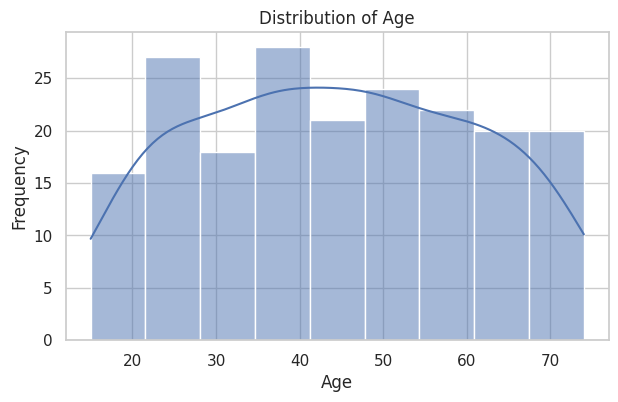

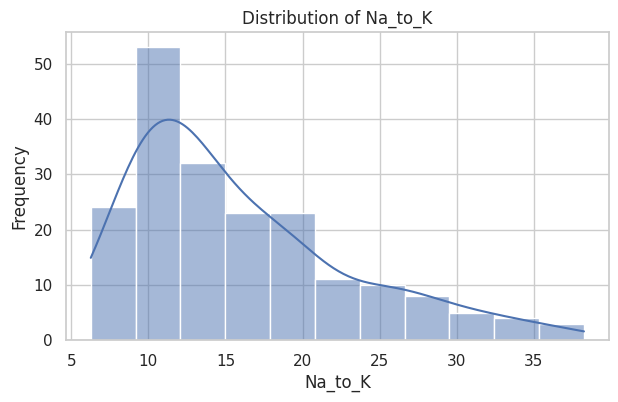

In [10]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Box Plot

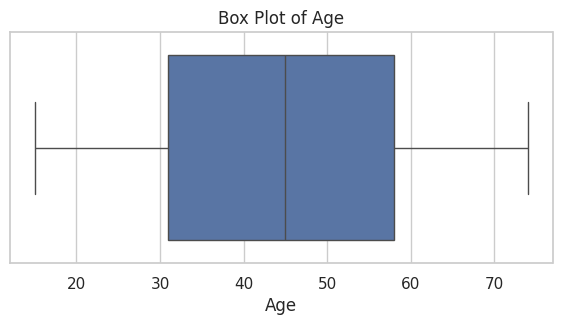

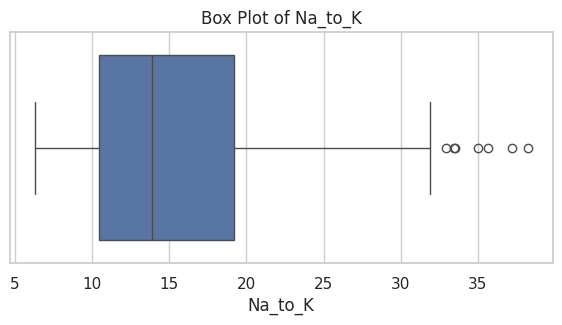

In [11]:
for col in num_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

# 1D Analysis of Categorical Variables

In [12]:
cat_cols = ["Sex", "BP", "Cholesterol", "Drug"]

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 Sex
Sex
M    103
F     93
Name: count, dtype: int64

 BP
BP
HIGH      74
LOW       64
NORMAL    58
Name: count, dtype: int64

 Cholesterol
Cholesterol
HIGH      100
NORMAL     96
Name: count, dtype: int64

 Drug
Drug
DrugY    87
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


# Bar Charts for Categorical Variables

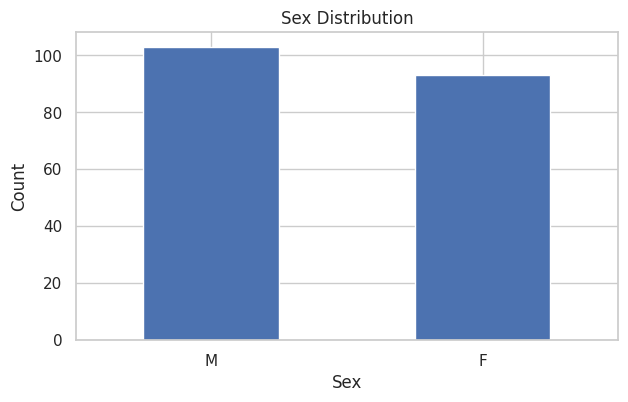

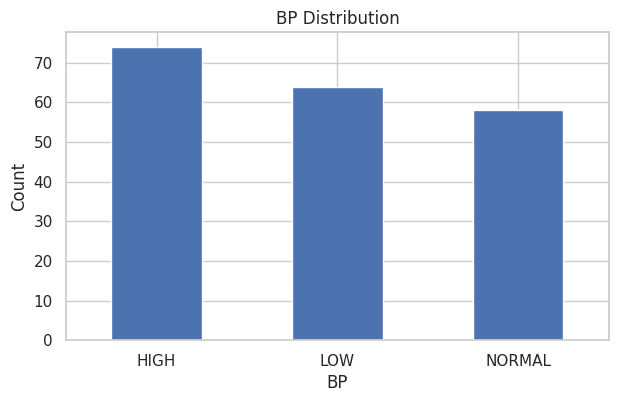

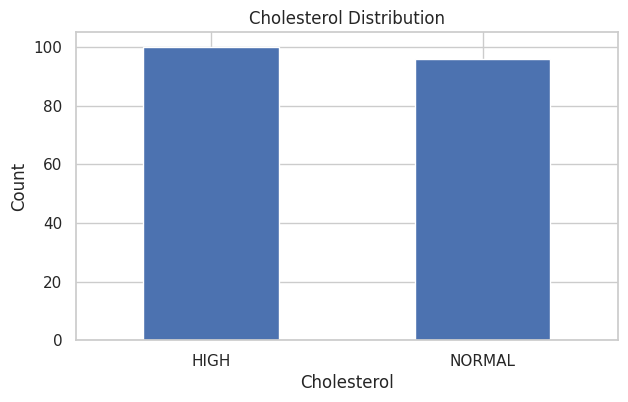

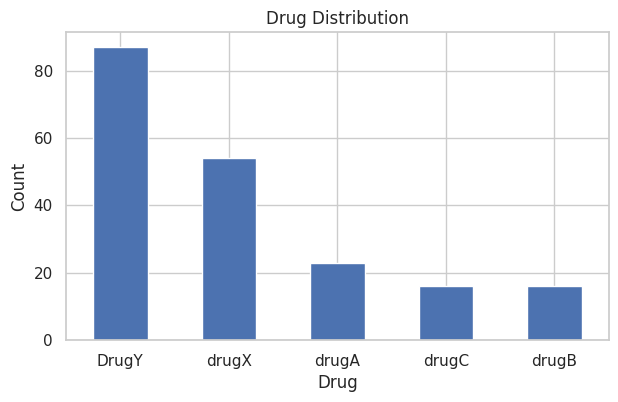

In [13]:
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

# Pie Chart

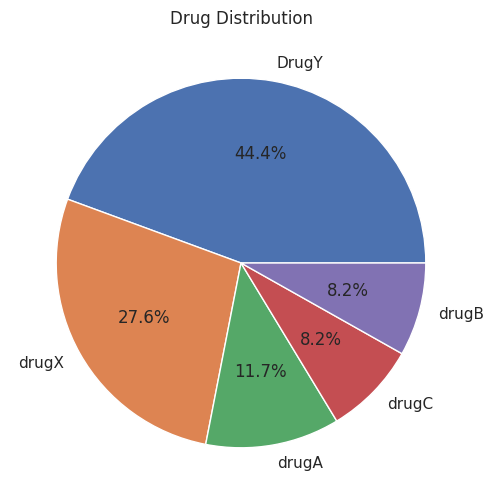

In [14]:
df["Drug"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.title("Drug Distribution")
plt.ylabel("")
plt.show()

# 2D Statistical Analysis
## Two Categorical Variables

In [15]:
table = pd.crosstab(df["BP"], df["Drug"])

print(table)

Drug    DrugY  drugA  drugB  drugC  drugX
BP                                       
HIGH       35     23     16      0      0
LOW        30      0      0     16     18
NORMAL     22      0      0      0     36


# Contingency Table and Chi-Square Test

In [16]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

Chi-square: 143.55081225696568
p-value: 4.329004408653986e-27
Degrees of freedom: 8

Expected frequencies:
Drug        DrugY     drugA     drugB     drugC      drugX
BP                                                        
HIGH    32.846939  8.683673  6.040816  6.040816  20.387755
LOW     28.408163  7.510204  5.224490  5.224490  17.632653
NORMAL  25.744898  6.806122  4.734694  4.734694  15.979592


# Heatmap of Contingency Table

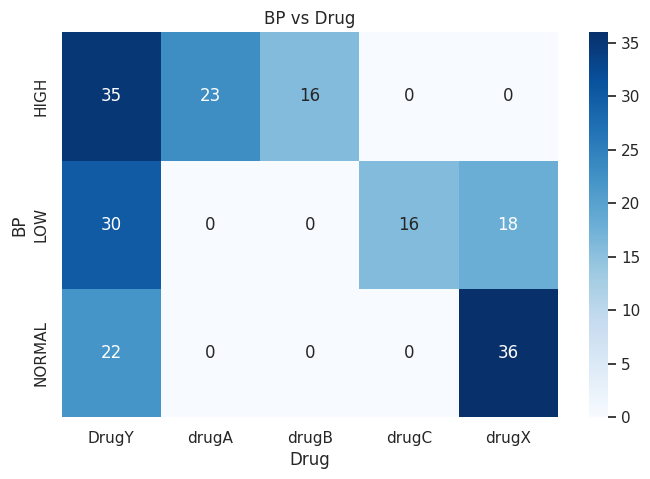

In [17]:
plt.figure(figsize=(8, 5))
sns.heatmap(table, annot=True, fmt="d", cmap="Blues")
plt.title("BP vs Drug")
plt.xlabel("Drug")
plt.ylabel("BP")
plt.show()

# 2D Analysis of Two Quantitative Variables
## Scatter Plot

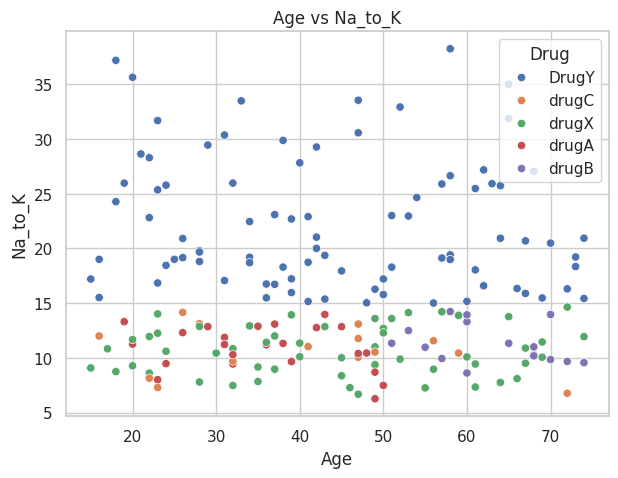

In [18]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Age", y="Na_to_K", hue="Drug")
plt.title("Age vs Na_to_K")
plt.xlabel("Age")
plt.ylabel("Na_to_K")
plt.show()

# Correlation

In [19]:
correlation = df["Age"].corr(df["Na_to_K"])

print("Pearson correlation:", correlation)

Pearson correlation: -0.0628572855514047


# Correlation Matrix

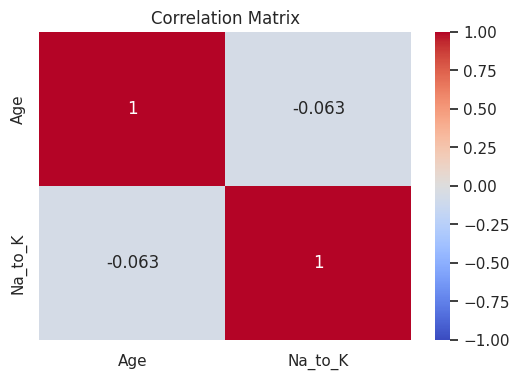

In [20]:
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# 2D Analysis of a Quantitative and a Categorical Variable
## Grouped Statistics

In [21]:
df.groupby("Drug")["Na_to_K"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Drug,,,,,,
DrugY,87,22.209598,20.0130,5.992599,15.015,38.247
drugA,23,10.918783,11.2270,2.037642,6.269,13.972
drugB,16,11.524375,11.1745,1.869919,8.621,14.239
drugC,16,10.633750,10.4905,2.045009,6.769,14.160
drugX,54,10.650556,10.5240,2.198091,6.683,14.642


# Box Plot: Quantitative vs Categorical

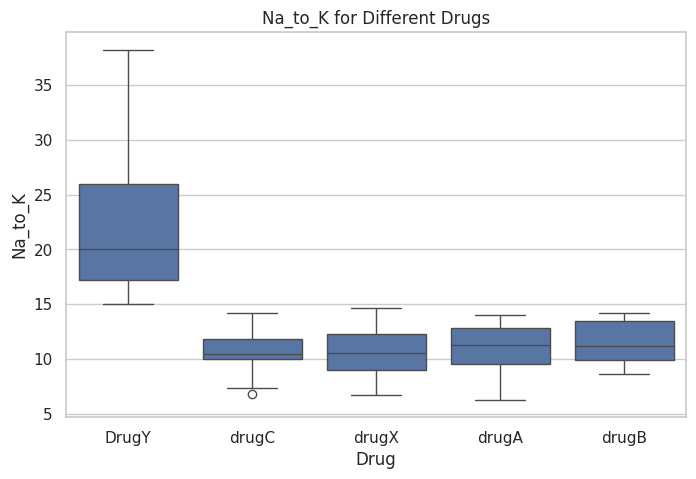

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Drug", y="Na_to_K")
plt.title("Na_to_K for Different Drugs")
plt.xlabel("Drug")
plt.ylabel("Na_to_K")
plt.show()

# Violin Plot

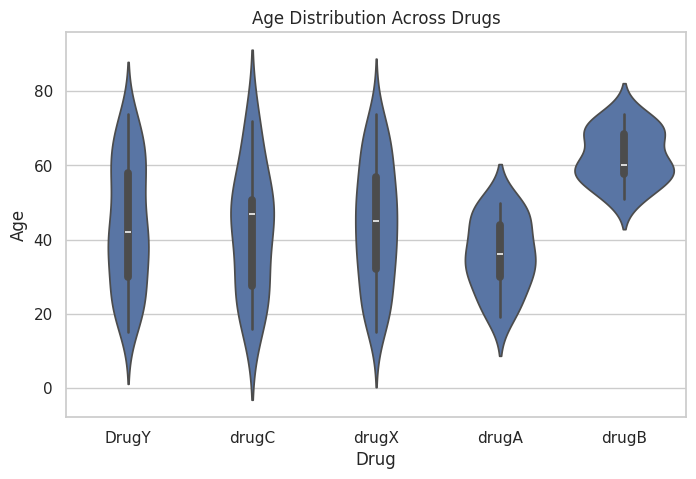

In [23]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Drug", y="Age")
plt.title("Age Distribution Across Drugs")
plt.xlabel("Drug")
plt.ylabel("Age")
plt.show()

# 3D Statistical Analysis
## One Categorical Variable and Two Quantitative Variables

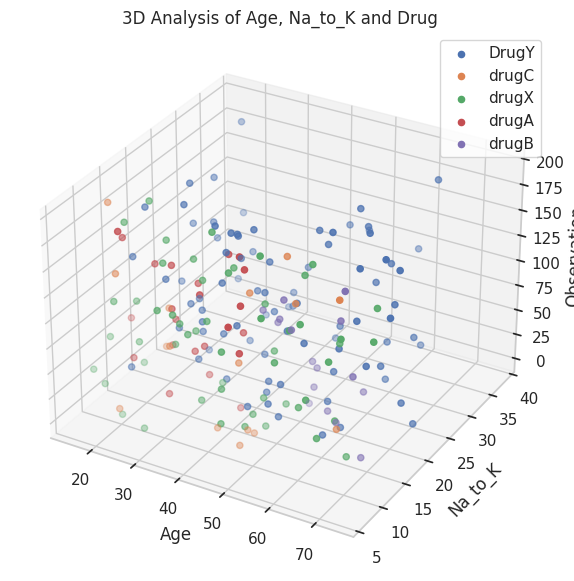

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for drug in df["Drug"].unique():
    temp = df[df["Drug"] == drug]

    ax.scatter(
        temp["Age"],
        temp["Na_to_K"],
        temp.index,
        label=drug
    )

ax.set_xlabel("Age")
ax.set_ylabel("Na_to_K")
ax.set_zlabel("Observation")
ax.set_title("3D Analysis of Age, Na_to_K and Drug")
ax.legend()

plt.show()

# 3D Analysis Using BP, Sex and Age
## Quantitative Variable with Two Categorical Variables

In [25]:
grouped = df.groupby(["BP", "Sex"])["Age"].agg(
    ["mean", "median", "std", "min", "max"]
)

grouped

mean  median        std  min  max
BP     Sex                                        
HIGH   F    37.742857    35.0  16.695091   16   73
       M    46.512821    48.0  17.696077   15   74
LOW    F    46.107143    44.5  14.760657   20   74
       M    47.750000    47.0  14.701555   16   74
NORMAL F    45.233333    48.0  16.449889   18   73
       M    43.428571    48.0  17.502230   15   67

# 3D Grouped Visualization

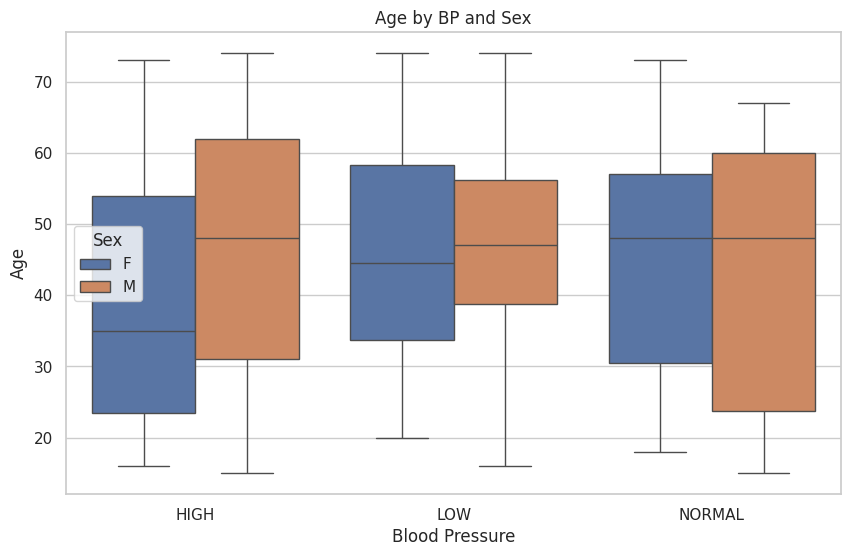

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="BP",
    y="Age",
    hue="Sex"
)

plt.title("Age by BP and Sex")
plt.xlabel("Blood Pressure")
plt.ylabel("Age")
plt.show()

# K-Means Clustering
## Selecting Numerical Features

In [27]:
num_features = df.select_dtypes(include=np.number).columns
X = df[num_features]

print("Numerical features:")
print(X.columns.tolist())

X.head()

Numerical features:
['Age', 'Na_to_K']


,Age,Na_to_K
0,23,25.355
1,47,13.093
2,47,10.114
3,28,7.798
4,61,18.043


# Standardizing the Data

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Age,Na_to_K
0,-1.303775,1.337984
1,0.152985,-0.394068
2,0.152985,-0.814863
3,-1.000283,-1.142006
4,1.002761,0.305137


# Applying K-Means Clustering
## Number of Clusters = 3

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["Age", "Na_to_K", "Cluster"]].head(10)

,Age,Na_to_K,Cluster
0,23,25.355,0
1,47,13.093,1
2,47,10.114,1
3,28,7.798,2
4,61,18.043,1
5,22,8.607,2
6,49,16.275,1
7,41,11.037,2
8,60,15.171,1
9,43,19.368,0


# Displaying K-Means Results

In [30]:
print(df["Cluster"].value_counts().sort_index())

df[["Age", "Na_to_K", "Cluster"]]

Cluster
0    40
1    83
2    73
Name: count, dtype: int64


,Age,Na_to_K,Cluster
0,23,25.355,0
1,47,13.093,1
2,47,10.114,1
3,28,7.798,2
4,61,18.043,1
...,...,...,...
191,56,11.567,1
192,16,12.006,2
193,52,9.894,1
194,23,14.020,2


#Cluster Centers

In [31]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=num_features
)

centers.index = ["Cluster 0", "Cluster 1", "Cluster 2"]

centers

,Age,Na_to_K
Cluster 0,41.450000,27.503425
Cluster 1,58.578313,12.729217
Cluster 2,30.109589,13.100890


#WCSS

In [32]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

for k, value in enumerate(wcss, start=1):
    print("K =", k, "WCSS =", value)

K = 1 WCSS = 391.9999999999998
K = 2 WCSS = 245.6036247185573
K = 3 WCSS = 138.80824392722158
K = 4 WCSS = 109.0398558332858
K = 5 WCSS = 85.29509922676158
K = 6 WCSS = 68.0247865282332
K = 7 WCSS = 55.60890725368421
K = 8 WCSS = 49.0310791543099
K = 9 WCSS = 44.05334883177483
K = 10 WCSS = 38.70164789281275


# Elbow Plot

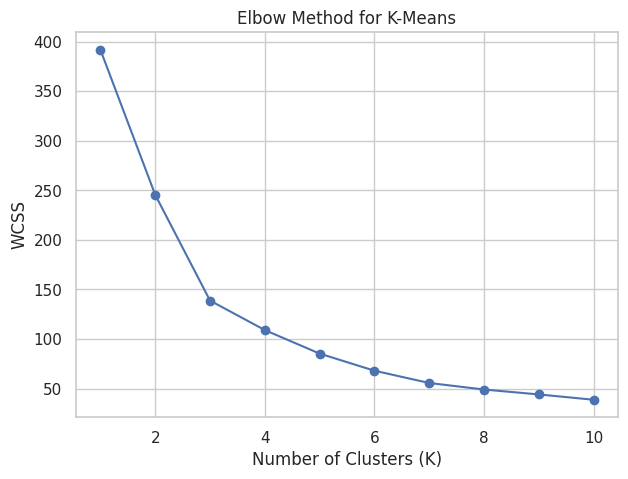

In [33]:
plt.figure(figsize=(7, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")

plt.show()

# Visualizing K-Means Clusters

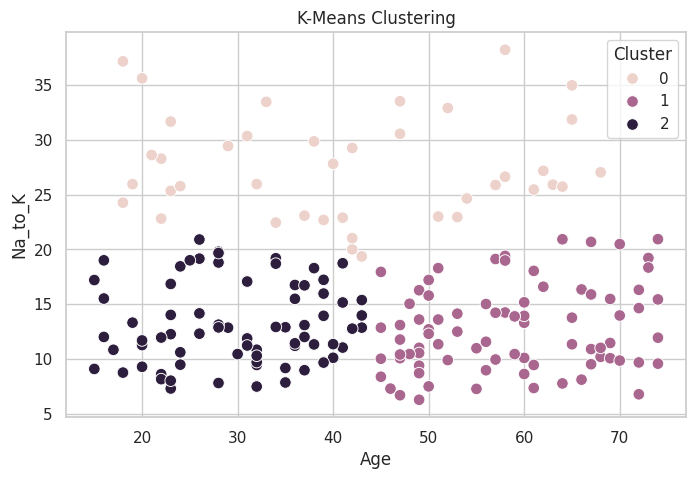

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Na_to_K",
    hue="Cluster",
    s=70
)

plt.title("K-Means Clustering")
plt.xlabel("Age")
plt.ylabel("Na_to_K")

plt.show()

# Hierarchical Clustering
## Dendrogram for 50 Records

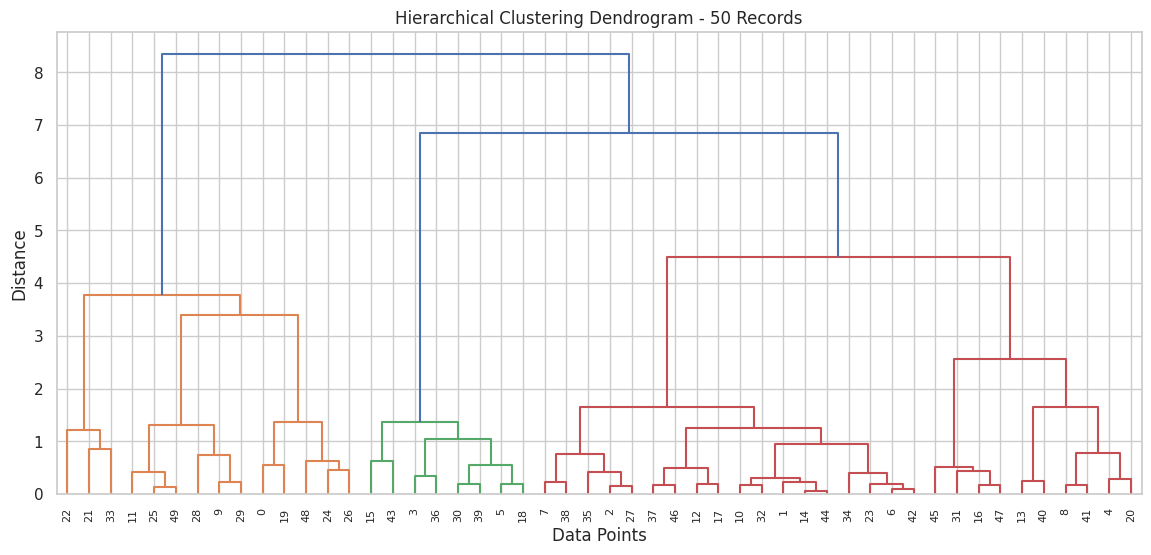

In [39]:
X_50 = X_scaled[:50]

linked_50 = linkage(X_50, method="ward")

plt.figure(figsize=(14, 6))

dendrogram(linked_50)

plt.title("Hierarchical Clustering Dendrogram - 50 Records")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# Applying Agglomerative Hierarchical Clustering
## Number of Clusters = 3

In [40]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)

df[["Age", "Na_to_K", "Hierarchical_Cluster"]].head(10)

,Age,Na_to_K,Hierarchical_Cluster
0,23,25.355,0
1,47,13.093,1
2,47,10.114,1
3,28,7.798,1
4,61,18.043,2
5,22,8.607,1
6,49,16.275,1
7,41,11.037,1
8,60,15.171,2
9,43,19.368,1


# Displaying Hierarchical Clustering Results

In [41]:
print(df["Hierarchical_Cluster"].value_counts().sort_index())

df[["Age", "Na_to_K", "Hierarchical_Cluster"]]

Hierarchical_Cluster
0    51
1    93
2    52
Name: count, dtype: int64


,Age,Na_to_K,Hierarchical_Cluster
0,23,25.355,0
1,47,13.093,1
2,47,10.114,1
3,28,7.798,1
4,61,18.043,2
...,...,...,...
191,56,11.567,2
192,16,12.006,1
193,52,9.894,1
194,23,14.020,1


# Visualizing Hierarchical Clusters

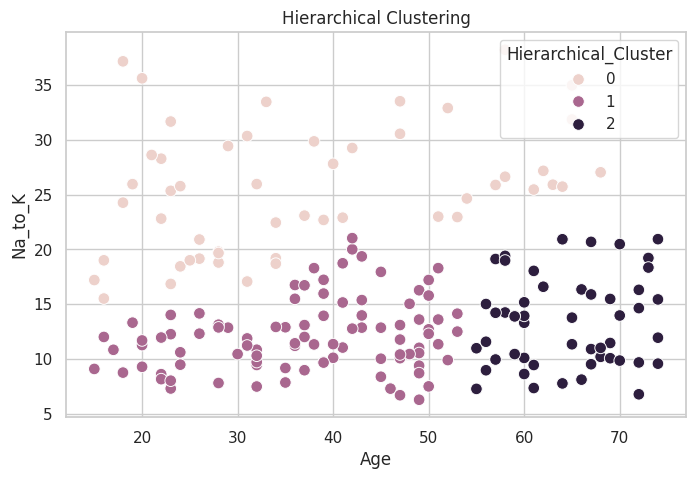

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Na_to_K",
    hue="Hierarchical_Cluster",
    s=70
)

plt.title("Hierarchical Clustering")
plt.xlabel("Age")
plt.ylabel("Na_to_K")

plt.show()